<a href="https://colab.research.google.com/github/sasanun/KnitChartGenerator/blob/main/KnitChartGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# アグリーセーターの編み図を生成する

## クラスや関数の定義

### パッケージのインストール

In [ ]:
!pip install svgwrite
!pip install svgpathtools
!pip install jinja2
!pip install enum34

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.3 MB/s eta 0:00:00


### 画像を加工しRGBカラーコードの配列を生成するまでの一連の関数を定義する

In [ ]:
from PIL import Image
from IPython.display import display
from typing import Self
import os
import math
import csv
import random
import string
import re
import numpy as np
from enum import Enum

def load_image(file_path: str):
    """
    指定されたファイルパスから画像を読み込み、PIL Imageオブジェクトとして返します。
    ファイルがImageとして読み込めない場合はエラーを出力しNoneを返します。
    読み込めた場合はファイルの詳細をprintで表示します。

    Args:
        file_path (str): 読み込む画像のファイルパス。

    Returns:
        (str, PIL.Image.Image) or None: ファイル名と読み込まれたPIL Imageオブジェクト、
                                  または読み込みに失敗した場合はNone。
    """
    if not isinstance(file_path, str):
        print("エラー: ファイルパスは文字列である必要があります。")
        return None

    if not os.path.exists(file_path):
        print(f"エラー: ファイルが見つかりません - {file_path}")
        return None

    try:
        # ファイル名を取得する
        _filename = os.path.basename(file_path)

        # 画像として開いてみる
        _img = Image.open(file_path)

        # ファイルの詳細を表示
        print(f"\n画像を正常に読み込みました: {file_path}")
        print(f"  形式: {_img.format}")
        print(f"  モード: {_img.mode}")
        print(f"  サイズ: {_img.size} ピクセル (幅x高さ)")
        if _img.info:
            print("  追加情報:")
            for key, value in _img.info.items():
                 # 大きすぎる情報は表示しない
                if len(str(value)) < 100:
                    print(f"    {key}: {value}")


        # PIL Imageオブジェクトを返す
        return _filename, _img

    except FileNotFoundError:
        print(f"エラー: ファイルが見つかりません - {file_path}")
        return None
    except Exception as e:
        print(f"エラー: ファイルを画像として読み込めませんでした - {file_path}")
        print(f"詳細: {e}")
        return None

default_palett = [
    '#FF0000',  # 明るい赤
    '#0000FF',  # 純粋な青
    '#008000',  # 深い緑
    '#FFFF00',  # 鮮やかな黄
    '#FFA500',  # オレンジ
    '#800080',  # 紫
    '#00FFFF',  # シアン（水色）
    '#FFC0CB',  # ピンク
    '#A52A2A',  # 茶色
    '#FFFFFF'   # 白
    ]

monochrome_pallet = [
    '#A52A2A',  # 茶色
    '#FFFFFF'   # 白
    ]


class Uglizer:
    """
    画像を加工してアグリーニットのための配列を生成する。

    """

    def __init__(self, name: str, img: Image.Image, palette = None):
        self.name = name
        self._original_image = img
        self._current_image = img.copy()
        if palette is None:
            self._palette = [] # Initialize as a list
        else:
            self._palette = list(palette) # Initialize as a list

    @property
    def original_image(self) -> Image.Image:
        return self._original_image

    @property
    def current_image(self) -> Image.Image:
        return self._current_image

    @property
    def palette(self) -> list:
        return self._palette

    def _is_valid_hex_color(hex_color: str) -> bool:
        """
        指定された文字列が有効なHEXカラーコード形式であるかチェックします (#FFFFFF または #fff の形式)。

        Args:
            hex_color (str): チェックする文字列。

        Returns:
            bool: 有効なHEXカラーコード形式であればTrue、そうでなければFalse。
        """
        if not isinstance(hex_color, str):
            return False
        # #RGB または #RRGGBB の形式に一致するかチェック
        return re.match(r'^#([A-Fa-f0-9]{6}|[A-Fa-f0-9]{3})$', hex_color) is not None


    def add_color(self, color_hex: str) -> int:
        """
        指定されたHEXカラーコードをパレットに追加します。
        無効な形式や既に存在する色はスキップされます。

        Args:
            color_hex (str): 追加する色のHEXカラーコード。

        Returns:
            int: 処理結果 (0: エラー、1: 成功)
        """
        if not self._is_valid_hex_color(color_hex):
            print(f"エラー: '{color_hex}' は無効なHEXカラーコード形式です。")
            return 0

        upper_palette = [color.upper() for color in self._palette]
        if color_hex.upper() in upper_palette:
            print(f"注意: '{color_hex}' は既にパレットに含まれています。")
            return 0

        self._palette.append(color_hex.upper())
        print(f"'{color_hex}' をパレットに追加しました。")
        return 1

    def add_colors(self, color_hex_list: list[str]) -> int:
        """
        指定されたHEXカラーコードのリストをパレットに追加します。
        無効な形式や既に存在する色の判定はadd_color関数にて行います。

        Args:
            color_hex_list (list[str]): 追加する色のHEXカラーコードのリスト。

        Returns:
            int: パレットに追加された色の数
        """
        added_count = 0
        for color_hex in color_hex_list:
            added = self.add_color(color_hex)
            added_count += added

        if added_count > 0:
            print(f"\n{len(color_hex_list)}色のうち、{added_count} 色をパレットに追加しました。")
        else:
            print("\n有効な色がパレットに追加されませんでした。")

        return added_count

    def add_midtone(self, primary_color_hex: str, secondary_color_hex: str) -> int:
        """
        指定された2つの色の間の中間色を計算し、パレットに追加します。
        無効な形式や既に存在する中間色はスキップされます。

        Args:
            primary_color_hex (str): 1番目の色のHEXカラーコード。
            secondary_color_hex (str): 2番目の色のHEXカラーコード。

        Returns:

        """
        if not self._is_valid_hex_color(primary_color_hex) or not self._is_valid_hex_color(secondary_color_hex):
            print("\n有効なHEXカラーコードを2つ指定してください。")
            return 0

        midtone = self._generate_midtone(primary_color_hex, secondary_color_hex)

        return self.add_color(midtone)

    def add_colors_with_midtone(self, primary_color_hex: str, secondary_color_hex: str) -> int:
        """
        指定された2つの色と、その中間色を計算し、パレットに追加します。

        Args:
            primary_color_hex (str): 1番目の色のHEXカラーコード。
            secondary_color_hex (str): 2番目の色のHEXカラーコード。

        Returns:
            int: パレットに追加された色の数
        """
        if not self._is_valid_hex_color(primary_color_hex) or not self._is_valid_hex_color(secondary_color_hex):
            print("エラー: 有効なHEXカラーコードを2つ指定してください。")
            return 0
        added_count = 0
        added_count += self.add_color(primary_color_hex)
        added_count += self.add_color(secondary_color_hex)
        added_count += self.add_midtone(primary_color_hex, secondary_color_hex)
        return added_count



    def _generate_midtone(self, primary_color_hex: str, secondary_color_hex: str) -> str:
        """
        2つの色の中間色を生成し返します。

        Args:
            primary_color_hex (str): 1番目の色のHEXカラーコード。
            secondary_color_hex (str): 2番目の色のHEXカラーコード。

        Returns:
            str: 中間色のHEXカラーコード。中間色は小数点以下を丸めて整数化されます。

        Raises:
            ValueError: HEXカラーコードの形式が不正な場合。
        """

        # 基本色をRGBタプルに変換
        color1 = np.array(self._to_rgb(primary_color_hex))
        color2 = np.array(self._to_rgb(secondary_color_hex))

        # 2色の中間色を計算（平均値）
        mid_color_rgb = (color1 + color2) / 2.0

        # RGB値を0-255の範囲に丸めて整数化
        mid_color_rgb_int = tuple(np.round(np.clip(mid_color_rgb, 0, 255)).astype(int))

        return self._to_hex(mid_color_rgb_int)

    def remove_color(self, color_hex: str):
        """
        指定されたHEXカラーコードをパレットから削除します。
        大文字・小文字は区別されません。指定された色がパレットに存在しない場合は警告を表示します。

        Args:
            color_hex (str): 削除する色のHEXカラーコード。
        """
        upper_palette = [color.upper() for color in self._palette]
        try:
            index = upper_palette.index(color_hex.upper())
            self._palette.pop(index)
            print(f'\n{color_hex} をパレットから削除しました。')
        except ValueError:
            print(f'\n{color_hex} はパレットに存在しません。')
        return

    def clear_palette(self):
        """
        パレットの全ての色を削除します。
        """
        self._palette = []
        print("パレットをクリアしました。")
        return

    def resize_height_factor(self, height_factor: float) -> Self:
        """
        Imageオブジェクトの横方向のピクセル数をそのままに、縦方向を任意の倍率に変更します。
        アスペクト比は維持されません。

        Args:
            height_factor (float): 縦方向にかける倍率。1.0で元の高さ、2.0で2倍の高さになります。
                                負の数や0は許可されません。

        Raises:
            ValueError: height_factorが負の数または0の場合。
            Exception: その他の画像処理エラー。
        """
        if not isinstance(height_factor, (int, float)) or height_factor <= 0:
            raise ValueError("height_factorは正の数値である必要があります。")

        try:
            original_width, original_height = self._current_image.size
            new_height = int(original_height * height_factor)
            self._current_image = self._current_image.resize((original_width, new_height), Image.Resampling.LANCZOS)
            print(f"\nImageオブジェクトをリサイズしました。")
            print(f"元のサイズ: {original_width}x{original_height}")
            print(f"新しいサイズ: {original_width}x{new_height} (高さ倍率: {height_factor})")

            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"画像の処理中にエラーが発生しました: {e}")


    def resize_width_pixel(self, width_pixel: int) -> Self:
        """
        Imageオブジェクトのアスペクト比を維持したまま、横方向のピクセル数を指定した値に変更します。
        縦方向のピクセル数は自動的に計算されます。

        Args:
            width_pixel (int): 変更したい目標の横方向ピクセル数。正の整数である必要があります。

        Raises:
            ValueError: target_widthが正の整数でない場合。
            Exception: その他の画像処理エラー。
        """
        if not isinstance(width_pixel, int) or width_pixel <= 0:
            raise ValueError("target_widthは正の整数である必要があります。")

        try:
            # 元の画像の幅と高さを取得
            original_width, original_height = self._current_image.size

            # アスペクト比を維持するための比率を計算
            # 新しい幅 / 元の幅 = 新しい高さ / 元の高さ
            # 新しい高さ = 元の高さ * (新しい幅 / 元の幅)
            aspect_ratio = original_height / original_width
            new_height = int(width_pixel * aspect_ratio)

            # 新しいサイズで画像をリサイズ
            # Image.LANCZOS は高品質なリサイズアルゴリズムです
            self._current_image = self._current_image.resize((width_pixel, new_height), Image.Resampling.LANCZOS)

            print(f"\nImageオブジェクトをアスペクト比を維持してリサイズしました。")
            print(f"元のサイズ: {original_width}x{original_height}")
            print(f"新しいサイズ: {width_pixel}x{new_height} (横方向目標値: {width_pixel})")
            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"画像の処理中にエラーが発生しました: {e}")

    def resize_height_pixel(self, height_pixel: int) -> Self:
        """
        Imageオブジェクトのアスペクト比を維持したまま、縦方向のピクセル数を指定した値に変更します。
        横方向のピクセル数は自動的に計算されます。

        Args:
            height_pixel (int): 変更したい目標の縦方向ピクセル数。正の整数である必要があります。

        Raises:
            ValueError: target_widthが正の整数でない場合。
            Exception: その他の画像処理エラー。
        """
        if not isinstance(height_pixel, int) or height_pixel <= 0:
            raise ValueError("target_widthは正の整数である必要があります。")

        try:
            # 元の画像の幅と高さを取得
            original_width, original_height = self._current_image.size

            # アスペクト比を維持するための比率を計算
            # 新しい幅 / 元の幅 = 新しい高さ / 元の高さ
            # 新しい高さ = 元の高さ * (新しい幅 / 元の幅)
            aspect_ratio = original_width / original_height
            new_width = int(height_pixel * aspect_ratio)

            # 新しいサイズで画像をリサイズ
            # Image.LANCZOS は高品質なリサイズアルゴリズムです
            self._current_image = self._current_image.resize((new_width, height_pixel), Image.Resampling.LANCZOS)

            print(f"\nImageオブジェクトをアスペクト比を維持してリサイズしました。")
            print(f"元のサイズ: {original_width}x{original_height}")
            print(f"新しいサイズ: {new_width}x{height_pixel} (縦方向目標値: {height_pixel})")
            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"画像の処理中にエラーが発生しました: {e}")


    def resize_pixel(self, size: tuple) -> Self:
        if isinstance(size, tuple) and len(size) == 2 and all(isinstance(x, int) and x > 0 for x in size):
            width, height = size
            f_1 = width / height
            f_2 = self._current_image.width / self._current_image.height
            if f_1 < f_2:
                self.resize_width_pixel(width)
            else:
                self.resize_height_pixel(height)
        else:
            raise ValueError("サイズを正の整数タプルで指定してください。")


    def _to_rgb(self, hex: str):
        """
        HEXカラーコードをRGBタプルに変換します。

        Args:
            hex (str): 変換するHEXカラーコード (例: '#FF0000' または '#f00')。

        Returns:
            tuple: RGB値のタプル (例: (255, 0, 0))。
        """
        hex = hex.removeprefix("#")
        # Handle both #RGB and #RRGGBB formats
        if len(hex) == 3:
            hex = ''.join([c*2 for c in hex])
        return tuple(int(hex.lower()[i:i+2], 16) for i in (0, 2, 4))

    def _to_hex(self, rgb: tuple) -> str:
        """
        RGBタプルをHEXカラーコードに変換します (例: (255, 0, 0) -> '#FF0000')。

        Args:
            rgb (tuple): RGB値のタプル (例: (255, 0, 0))。

        Returns:
            str: 変換されたHEXカラーコード (例: '#FF0000')。
        """
        return f"#{int(rgb[0]):02X}{int(rgb[1]):02X}{int(rgb[2]):02X}"


    def _rgb_distance(self, color1, color2):
        """
        2つのRGB色の間のユークリッド距離を計算します。
        色の「近さ」を測るために使用します。

        Args:
            color1 (tuple): 1番目のRGBタプル (例: (255, 0, 0))。
            color2 (tuple): 2番目のRGBタプル (例: (0, 255, 0))。

        Returns:
            float: 2つの色の間のユークリッド距離。
        """
        r1, g1, b1 = color1
        r2, g2, b2 = color2
        return math.sqrt((r1 - r2)**2 + (g1 - g2)**2 + (b1 - b2)**2)

    def apply_palette(self) -> Self:
        """
        PIL Imageオブジェクトを、パレットの色だけで表現するように変換します。
        透過ピクセルは指定された閾値に基づいて処理されます。

        Raises:
            ValueError: _paletteが空の場合、または_imgが無効な場合。
            Exception: その他の画像処理エラー。
        """

        if not self._palette:  # Check if the list is empty
            raise ValueError("カスタムパレットは空であってはなりません。少なくとも1色指定してください。")

        # HEXカラーコードをRGBタプルに変換
        palette_rgb = [self._to_rgb(color) for color in self._palette]

        try:
            # 画像をRGBAモードに変換（もし可能であれば）
            img_rgba = self._current_image.convert("RGBA")

            # 新しい画像を作成 (元の画像と同じサイズとRGBAモード)
            new_img = Image.new("RGBA", img_rgba.size)
            pixels = new_img.load() # 新しい画像のピクセルデータへのアクセス

            # 元画像のピクセルデータを取得
            original_pixels = img_rgba.load()

            width, height = img_rgba.size
            opacity_threshold = 127.5  # 50%の不透明度 (0-255スケール)

            # 全てのピクセルを走査し、透過度に基づいて処理
            for x in range(width):
                for y in range(height):
                    r, g, b, a = original_pixels[(x, y)]

                    if a < opacity_threshold:
                        # 不透明度が閾値未満の場合は完全な透明
                        pixels[(x, y)] = (0, 0, 0, 0)
                    else:
                        # 不透明度が閾値以上の場合は不透明として色をマッピング
                        original_rgb = (r, g, b)
                        closest_color = None
                        min_distance = float('inf')

                        for palette_color in palette_rgb:
                            distance = self._rgb_distance(original_rgb, palette_color)
                            if distance < min_distance:
                                min_distance = distance
                                closest_color = palette_color

                        if closest_color is not None:
                            pixels[(x, y)] = closest_color + (255,) # アルファ値を255に設定（完全不透明）
                        else:
                            # パレットが空の場合などの安全策 (通常は到達しないはず)
                            pixels[(x, y)] = original_rgb + (255,)
            self._current_image = new_img
            print(f"\n指定された色に変換しました。")
            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"\n画像の処理中にエラーが発生しました: {e}")

    def apply_checkerboard(self, target_hex: str, dither_colors_hex: tuple) -> Self:
        """
        PIL Imageオブジェクト内の特定のHEXカラーコードのピクセルを、
        指定された2色のHEXカラーコードで市松模様に変換します。

        Args:
            target_hex (str): 市松模様に変換する対象のHEXカラーコード (例: '#808080')。
                                透過情報は無視されます。
            dither_colors_hex (tuple): 市松模様を構成する2色のHEXカラーコードのタプル。 例: ('#000000', '#FFFFFF')
                                    正確に2色である必要があります。

        Raises:
            ValueError: imgが無効な場合、dither_colors_hexが2色でない場合、HEXコードの形式が不正な場合。
            Exception: その他の画像処理エラー。
        """
        if len(dither_colors_hex) != 2:
            raise ValueError("dither_colors_hex は正確に2色（HEXカラーコードのリスト）を指定してください。")

        try:
            target_rgb = self._to_rgb(target_hex)
            dither_colors_rgb = [self._to_rgb(color) for color in dither_colors_hex]
        except ValueError as e:
            raise ValueError(f"HEXカラーコードの形式が正しくありません: {e}")

        try:
            # 画像をRGBAモードに変換（アルファ値を保持するため）
            img_rgba = self._current_image.convert("RGBA")

            # 新しい画像を作成 (元の画像と同じサイズとRGBAモード)
            new_img = Image.new("RGBA", img_rgba.size)
            pixels = new_img.load() # 新しい画像のピクセルデータへのアクセス

            # 元画像のピクセルデータを取得
            original_pixels = img_rgba.load()

            width, height = img_rgba.size

            color1 = dither_colors_rgb[0]
            color2 = dither_colors_rgb[1]

            for x in range(width):
                for y in range(height):
                    r, g, b, a = original_pixels[(x, y)]
                    current_rgb = (r, g, b)

                    # 対象のRGBコードと現在のピクセルのRGBが一致するかチェック
                    # アルファ値は比較に含めない
                    if current_rgb == target_rgb:
                        # 市松模様のパターンを適用
                        if (x + y) % 2 == 0:
                            pixels[(x, y)] = color1 + (a,) # 元のアルファ値を保持
                        else:
                            pixels[(x, y)] = color2 + (a,) # 元のアルpha値を保持
                    else:
                        # 対象外のピクセルは元の色を保持
                        pixels[(x, y)] = (r, g, b, a)
            self._current_image = new_img
            print(f"\n指定されたHEXコード {target_hex} のピクセルを{color1}と{color2}の市松模様に変換しました。")
            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"\n画像の処理中にエラーが発生しました: {e}")

    def apply_transparent(self, hex: str) -> Self:
        """
        PIL Imageオブジェクト内の特定のHEXカラーコードのピクセルを、
        不透明度0の白に変換します。

        Args:
            hex (str): 透明に変換する対象のHEXカラーコード (例: '#FFFFFF')。

        Raises:
            ValueError: HEXコードの形式が不正な場合。
            Exception: その他の画像処理エラー。
        """
        try:
            target_rgb = self._to_rgb(hex)
        except ValueError as e:
            raise ValueError(f"HEXカラーコードの形式が正しくありません: {e}")

        try:
            # 画像をRGBAモードに変換
            img_rgba = self._current_image.convert("RGBA")

            # 新しい画像を作成 (元の画像と同じサイズとRGBAモード)
            new_img = Image.new("RGBA", img_rgba.size)
            pixels = new_img.load() # 新しい画像のピクセルデータへのアクセス

            # 元画像のピクセルデータを取得
            original_pixels = img_rgba.load()

            width, height = img_rgba.size

            for x in range(width):
                for y in range(height):
                    r, g, b, a = original_pixels[(x, y)]
                    current_rgb = (r, g, b)

                    # 対象のRGBコードと現在のピクセルのRGBが一致するかチェック
                    # アルファ値は比較に含めない
                    if current_rgb == target_rgb:
                        # 対象のピクセルを完全に透明な白に設定
                        pixels[(x, y)] = (255, 255, 255, 0)
                    else:
                        # 対象外のピクセルは元の色とアルファ値を保持
                        pixels[(x, y)] = (r, g, b, a)

            self._current_image = new_img
            print(f"\n指定されたHEXコード {hex} のピクセルを透明に変換しました。")
            display(self._current_image)
            return self

        except Exception as e:
            raise Exception(f"\n画像の処理中にエラーが発生しました: {e}")


    def to_array(self) -> list[int]:
        """
        PIL.Imageオブジェクト（RGBAモード）の各ピクセルを処理し、配列として返します。
        不透明度が50%以上のピクセルはRGBをカラーコードで、50%未満は空文字として配列要素とします。

        Returns:
            list[int]: 画像データから生成された配列。各要素はパレットのインデックスまたは空文字。
        """

        # 画像をRGBAモードに変換（もし異なるモードの場合でも対応できるように）
        rgba_image = self._current_image.convert("RGBA")

        # 画像データをNumPy配列に変換
        # shapeは (height, width, 4) となる (R, G, B, A)
        pixel_array = np.array(rgba_image)

        height, width, _ = pixel_array.shape
        result_array = np.empty((height, width), dtype=object) # Use dtype=object for string/empty string

        # 各行（画像の高さ）をループ
        for row_index in range(height):
            # 各列（画像の幅）をループ
            for col_index in range(width):
                r, g, b, a = pixel_array[row_index, col_index]

                # 不透明度が50%（255段階中127.5、整数なので128）以上かチェック
                if a >= 128:
                    # RGB部分を16進数のカラーコードに変換
                    hex_color = f"#{r:02x}{g:02x}{b:02x}".upper()
                    result_array[row_index, col_index] = hex_color
                else:
                    # 不透明度が50%未満の場合は空文字
                    result_array[row_index, col_index] = ""

        print("\n画像データが配列として生成されました。")
        return result_array.tolist()

### 指定されたゲージと寸法のセーターの編み図を生成するクラスを定義

In [ ]:
from dataclasses import dataclass        # データクラス定義用
from enum import Enum, auto              # 列挙型定義
import re                                # 正規表現
import math                              # 数学関数
import secrets                           # 安全な乱数生成
import numpy as np                       # 数値処理
from operator import index               # インデックス操作関連
from xml.etree import ElementTree        # XML/SVG の DOM 解析
import logging                           # TODO ロギング

# ============================
# サードパーティライブラリ
# ============================
import svgwrite                           # SVG 生成
from IPython.display import SVG, display  # Jupyter での SVG 表示

from svgpathtools import (                # SVG パス解析ツール
    parse_path,
    Line,
    CubicBezier,
    QuadraticBezier,
)

from shapely.geometry import (            # 形状処理（点・多角形）
    Point,
    Polygon,
    MultiPolygon,
)
from shapely.ops import unary_union       # ジオメトリ結合

from jinja2 import Template               # テンプレートエンジン

@dataclass(frozen=True)
class SweaterSizing:
    """
        セーターのサイズを定義するデータクラス。

        Args:
            length_of_body (int): 着丈 (mm)
            length_of_shoulder_drop (int): 肩下がり (mm)
            length_of_ribbed_hem (int): 裾のゴム編み (mm)
            length_of_front_neck_drop (int): 前襟ぐり下がり (mm)
            length_of_back_neck_drop (int): 後ろ襟ぐり下がり (mm)
            width_of_body (int): 身幅 (mm)
            width_of_neck (int): 襟ぐり幅 (mm)
            length_of_sleeve (int): 袖丈 (mm)
            length_of_ribbed_cuff (int): 袖口のゴム編み (mm)
            width_of_sleeve (int): 袖幅 (mm)
            width_of_cuff (int): 袖口幅 (mm)
    """
    length_of_body: int
    length_of_shoulder_drop: int
    length_of_ribbed_hem: int

    length_of_front_neck_drop: int
    length_of_back_neck_drop: int

    width_of_body: int
    width_of_neck: int
    length_of_sleeve: int
    length_of_ribbed_cuff: int

    width_of_sleeve: int
    width_of_cuff: int

@dataclass(frozen=True)
class KnitComponent:
    """ニット設計データの共通基底クラス"""
    id: str
    gauge_length: int
    gauge_width: int

@dataclass(frozen=True)
class SweaterChart(KnitComponent):
    """セーターの編み図"""
    front_body: np.ndarray
    back_body: np.ndarray
    sleeve: np.ndarray

@dataclass(frozen=True)
class SweaterShape(KnitComponent):
    """セーターの形状"""
    front_body: svgwrite.Drawing
    back_body: svgwrite.Drawing
    sleeve: svgwrite.Drawing

@dataclass(frozen=True)
class SweaterBlueprint(KnitComponent):
    """セーターの設計図"""
    front_body: svgwrite.Drawing
    back_body: svgwrite.Drawing
    sleeve: svgwrite.Drawing

class Align(Enum):
    LEFT_TOP = auto()
    CENTER_TOP = auto()
    RIGHT_TOP = auto()

    LEFT_CENTER = auto()
    CENTER = auto()
    RIGHT_CENTER = auto()

    LEFT_BOTTOM = auto()
    CENTER_BOTTOM = auto()
    RIGHT_BOTTOM = auto()

class SweaterChartGenerator:
    """
    セーターの設計情報を管理し、CSV形式で編み図を描画するクラスです。

    各寸法はmm単位で指定します。
    `length_of_body`や`width_of_horizontal_armhole`などのプロパティは、他の寸法から計算されます。
    これらの計算済みプロパティの値を変更すると、関連する寸法が自動的に調整されます。
    """

    def __init__(
            self,
            gauge_height: float,
            gauge_width: float,
            size: SweaterSizing,
            **kwargs
            ):
        """SweaterChartGeneratorクラスのインスタンスを初期化します。

        Args:
            gauge_height (float): ゲージ（10cmあたりの段数）
            gauge_width (float): ゲージ（10cmあたりの目数）
            size (SweaterSizing): セーターのサイズ
            is_reverse: 左右反転
            is_odd_width: 横の目数を奇数に調整する
        """
        self._initialized = False

        # ロガーの初期化
        self._logger = logging.getLogger(self.__class__.__name__)
        self._visibleLogLevel = kwargs.get("visibleLogLevel", logging.INFO)
        self._logger.setLevel(self._visibleLogLevel)
        if not self._logger.handlers:
            handler = logging.StreamHandler()
            formatter = logging.Formatter('%(levelname)s: %(message)s')
            handler.setFormatter(formatter)
            self._logger.addHandler(handler)

        self._id = secrets.token_hex(6) # ユニークなIDを生成

        # ゲージ
        self._gauge_length = gauge_height # Renamed from _gauge_height
        self._gauge_width = gauge_width

        # 編み図の反転
        self.is_reverse = kwargs.get("is_reverse", False)

        # 横の目数を奇数に調整する
        self.is_odd_width = kwargs.get("is_odd_width", False)

        # ボックス形状にする
        self.is_boxy = kwargs.get("is_boxy", False)

        # プロパティを初期化
        self.symbol_of_none_stich = kwargs.get("symbol_of_none_stich", "#")
        self.symbol_of_knit_stich = kwargs.get("symbol_of_knit_stich", "")
        self.symbol_of_purl_stich = kwargs.get("symbol_of_purl_stich", "-")
        self.symbol_of_cast_off = kwargs.get("symbol_of_cast_off", "●")
        self.symbol_of_k2tog = kwargs.get("symbol_of_k2tog", "／") # 右上2目1度
        self.symbol_of_ssk = kwargs.get("symbol_of_ssk", "＼") # 左上2目1度
        self.symbol_of_k1b = kwargs.get("symbol_of_k1b", "∨") # 1目編み出し

        # テストモード
        self._test = kwargs.get("_test", False)

        # セッターで値を更新
        self.length_of_body = size.length_of_body # 着丈
        self.length_of_shoulder_drop = size.length_of_shoulder_drop # 肩下がり
        self.length_of_ribbed_hem = size.length_of_ribbed_hem # 裾のゴム編み

        self.length_of_front_neck_drop = size.length_of_front_neck_drop # 前衿ぐりの深さ
        self.length_of_back_neck_drop = size.length_of_back_neck_drop # 後ろ衿ぐりの深さ

        self.width_of_body = size.width_of_body # 身幅
        self.width_of_neck = size.width_of_neck # 襟ぐり幅

        self.length_of_sleeve = size.length_of_sleeve # 袖丈
        self.length_of_ribbed_cuff = size.length_of_ribbed_cuff # 袖口のゴム編みの長さ

        self.width_of_sleeve = size.width_of_sleeve # 袖幅
        self.width_of_cuff = size.width_of_cuff # 袖口幅

        # シェイプ
        self._shape_of_front_body = None
        self._shape_of_back_body = None
        self._shape_of_sleeve = None

        # チャート
        self._chart_of_front_body = None
        self._chart_of_back_body = None
        self._chart_of_sleeve = None

        # シェイプとチャートの更新
        self._initialized = True
        self._update()

    # パーツ
    class Part(Enum):
        FRONT_BODY = "FRONT_BODY"
        BACK_BODY = "BACK_BODY"
        SLEEVE = "SLEEVE"

    # セクション
    class Section(Enum):
        FRONT_BODY_SHOULDER = "FRONT_BODY_SHOULDER"
        FRONT_BODY_TORSO = "FRONT_BODY_TORSO"
        FRONT_BODY_HEM = "FRONT_BODY_HEM"
        BACK_BODY_SHOULDE = "BACK_BODY_SHOULDE"
        BACK_BODY_TORSO = "BACK_BODY_TORSO"
        BACK_BODY_HEM = "BACK_BODY_HEM"
        SLEEVE_TOP = "SLEEVE_TOP"
        SLEEVE_MIDDLE = "SLEEVE_MIDDLE"
        SLEEVE_CUFF = "SLEEVE_CUFF"

    def __str__(self):
        # TODO
        pass

    def __repr__(self):
        #TODO
        pass

    @property
    def id(self) -> str:
        """このSweaterChartGeneratorインスタンスのユニークなIDです。"""
        return self._id

    @property
    def stitch_length(self):
        """1段の長さ(mm)。`gauge_height`から計算されます。"""
        return math.ceil(100000 / self.gauge_length) / 1000 # Changed from _gauge_height


    @property
    def stitch_width(self):
        """1目の幅(mm)。`gauge_width`から計算されます。"""
        return math.ceil(100000 / self._gauge_width) / 1000

    @property
    def gauge_length(self):
        """ゲージ（10cmあたりの段数）"""
        return self._gauge_length # Renamed from _gauge_height

    @gauge_length.setter # Renamed from gauge_height.setter
    def gauge_length(self, value):
        self._gauge_length = value # Renamed from _gauge_height
        if self._initialized:
            self._update()

    @property
    def gauge_width(self):
        """ゲージ（10cmあたりの目数）"""
        return self._gauge_width

    @gauge_width.setter
    def gauge_width(self, value):
        self._gauge_width = value
        if self._initialized:
            self._update()

    @property
    def gauge_factor(self):
        """1目の幅に対する1段の高さの比"""
        return self.gauge_width / self.gauge_length # Changed from self.gauge_height

    @property
    def is_reverse(self):
        """左右反転"""
        return self._is_reverse

    @is_reverse.setter
    def is_reverse(self, value):
        self._is_reverse = value
        if self._initialized:
            self._update()

    @property
    def is_odd_width(self):
        """横の目数を奇数に調整する"""
        return self._is_odd_width

    @is_odd_width.setter
    def is_odd_width(self, value):
        self._is_odd_width = value
        if self._initialized:
            self._update()

    # 着丈
    @property
    def length_of_body(self):
        """着丈の長さ(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_body / self.stitch_length) * self.stitch_length

    @length_of_body.setter
    def length_of_body(self, value):
        self._length_of_body = value
        if self._initialized:
            self._update()


    # 肩下がり
    @property
    def length_of_shoulder_drop(self):
        """肩下がり(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_shoulder_drop / self.stitch_length) * self.stitch_length

    @length_of_shoulder_drop.setter
    def length_of_shoulder_drop(self, value):
        self._length_of_shoulder_drop = value
        if self._initialized:
            self._update()

    # 袖付きの縦の長さ
    @property
    def length_of_vertical_armhole(self):
        """袖付の縦の長さ(mm)。袖幅と同じ長さです。"""
        return self.width_of_sleeve

    # わき丈
    @property
    def length_of_side(self):
        """脇下から裾の上端までの長さ(mm)。"""
        return self.length_of_body - self.length_of_shoulder_drop - self.length_of_vertical_armhole -self.length_of_ribbed_hem

    # 裾のゴム編みの長さ
    @property
    def length_of_ribbed_hem(self):
        """裾の長さ(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_ribbed_hem / self.stitch_length) * self.stitch_length

    @length_of_ribbed_hem.setter
    def length_of_ribbed_hem(self, value):
        self._length_of_ribbed_hem = value
        if self._initialized:
            self._update()

    # 前襟ぐり下がり
    @property
    def length_of_front_neck_drop(self):
        """前襟ぐり下がり(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_front_neck_drop / self.stitch_length) * self.stitch_length

    @length_of_front_neck_drop.setter
    def length_of_front_neck_drop(self, value):
        self._length_of_front_neck_drop = value
        if self._initialized:
            self._update()

    # 後襟ぐり下がり
    @property
    def length_of_back_neck_drop(self):
        """後ろ襟ぐり下がり(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_back_neck_drop / self.stitch_length) * self.stitch_length

    @length_of_back_neck_drop.setter
    def length_of_back_neck_drop(self, value):
        self._length_of_back_neck_drop = value
        if self._initialized:
            self._update()

    # 身幅
    @property
    def width_of_body(self):
        """身幅(mm)。`stitch_width`の偶数倍または奇数倍に丸められます。"""
        if self.is_odd_width:
            return int(self._width_of_body / self.stitch_width / 2) * 2 * self.stitch_width + self.stitch_width
        else:
            return int(self._width_of_body / self.stitch_width / 2) * 2 * self.stitch_width

    @width_of_body.setter
    def width_of_body(self, value):
        self._width_of_body = value
        if self._initialized:
            self._update()

    # 袖ぐりの水平方向の長さ
    @property
    def width_of_horizontal_armhole(self):
        """袖付の横の長さ(mm)。身幅のおよそ1/10の長さです。"""
        return int((self.width_of_body * 0.1) / self.stitch_width) * self.stitch_width

    # 肩幅
    @property
    def width_of_shoulder(self):
        """肩幅(mm)。身幅から袖付の横の長さと襟ぐり幅を引いた長さです。"""
        return (self.width_of_body - self.width_of_horizontal_armhole * 2 - self.width_of_neck) / 2

    # 襟ぐり幅
    @property
    def width_of_neck(self):
        """襟ぐり幅(mm)。`stitch_width`の偶数倍に丸められます。"""
        return int(self._width_of_neck / self.stitch_width / 2) * 2 * self.stitch_width

    @width_of_neck.setter
    def width_of_neck(self, value):
        self._width_of_neck = value
        if self._initialized:
            self._update()

    # 袖丈
    @property
    def length_of_sleeve(self):
        """袖丈(mm)。`stitch_length`の整数倍に丸められます。"""
        return int(self._length_of_sleeve / self.stitch_length) * self.stitch_length

    @length_of_sleeve.setter
    def length_of_sleeve(self, value):
        self._length_of_sleeve = value
        if self._initialized:
            self._update()

    # 袖山の高さ
    @property
    def length_of_sleeve_cap(self):
        """袖山の高さ(mm)。袖ぐりの横の長さの2倍の長さです。"""
        return int((self.width_of_horizontal_armhole * 2) / self.stitch_length) * self.stitch_length

    # 袖下の長さ
    @property
    def length_of_sleeve_bottom(self):
        """袖下の長さ(mm)。"""
        return self.length_of_sleeve - self.length_of_sleeve_cap - self.length_of_ribbed_cuff

    # 袖口のゴム編みの長さ
    @property
    def length_of_ribbed_cuff(self):
        """袖口のゴム編みの長さ(mm)。`stitch_length`の整数倍または(整数+1/2)倍に丸められます。"""
        if self.is_odd_width:
            return int((self.length_of_ribbed_cuff) / self.stitch_length) * self.stitch_length + self.stitch_length / 2
        else:
            return int(self._length_of_ribbed_cuff / self.stitch_length) * self.stitch_length

    @length_of_ribbed_cuff.setter
    def length_of_ribbed_cuff(self, value):
        self._length_of_ribbed_cuff = value
        if self._initialized:
            self._update()

    # 袖幅
    @property
    def width_of_sleeve(self):
        """袖幅(mm)。`stitch_width`の整数倍または(整数+1/2)倍に丸められます。"""
        if self.is_odd_width:
            return int(self._width_of_sleeve / self.stitch_width) * self.stitch_width + self.stitch_width / 2
        else:
            return int(self._width_of_sleeve / self.stitch_width) * self.stitch_width

    @width_of_sleeve.setter
    def width_of_sleeve(self, value):
        self._width_of_sleeve = value
        if self._initialized:
            self._update()

    # 袖口の幅
    @property
    def width_of_cuff(self):
        """袖口の幅(mm)。`stitch_width`の整数倍に丸められます。"""
        return int(self._width_of_cuff / self.stitch_width) * self.stitch_width

    @width_of_cuff.setter
    def width_of_cuff(self, value):
        self._width_of_cuff = value
        if self._initialized:
            self._update()

    def get_pattern_size_of_body(self) -> tuple:
        """
        身頃のパターン描画可能領域のサイズを返します。

        Returns:
            size(tuple): (横の目数, 縦の段数)
        """
        return (int(self.width_of_body / self.stitch_width), int((self.length_of_body - self.length_of_ribbed_hem) / self.stitch_length))

    def get_pattern_size_of_sleeve(self) -> tuple:
        """
        袖のパターン描画可能領域を返します。

        Returns:
            size(tuple): (横の目数, 縦の段数)
        """
        return (int(self.width_of_sleeve / self.stitch_width), int((self.length_of_sleeve - self.length_of_ribbed_cuff) / self.stitch_length))

    def get_size(self) -> SweaterSizing:
        return SweaterSizing(
            length_of_body=self.length_of_body,
            length_of_shoulder_drop=self.length_of_shoulder_drop,
            length_of_ribbed_hem=self.length_of_ribbed_hem,
            length_of_front_neck_drop=self.length_of_front_neck_drop,
            length_of_back_neck_drop=self.length_of_back_neck_drop,
            width_of_body=self.width_of_body,
            width_of_neck=self.width_of_neck,
            length_of_sleeve=self.length_of_sleeve,
            length_of_ribbed_cuff=self.length_of_ribbed_cuff,
            width_of_sleeve=self.width_of_sleeve,
            width_of_cuff=self.width_of_cuff,
            )

    def get_shape(self):
        return SweaterShape(
            id=self.id,
            gauge_length=self.gauge_length,
            gauge_width=self.gauge_width,
            front_body=self._shape_of_front_body,
            back_body=self._shape_of_back_body,
            sleeve=self._shape_of_sleeve
        )

    def get_blueprint(self):
        return SweaterBlueprint(
            id=self.id,
            gauge_length=self.gauge_length,
            gauge_width=self.gauge_width,
            front_body=self._convert_to_blueprint(self._shape_of_front_body),
            back_body=self._convert_to_blueprint(self._shape_of_back_body),
            sleeve=self._convert_to_blueprint(self._shape_of_sleeve)
        )

    def get_chart(self):
        return SweaterChart(
            id=self.id,
            gauge_length=self.gauge_length,
            gauge_width=self.gauge_width,
            front_body=self._chart_of_front_body,
            back_body=self._chart_of_back_body,
            sleeve=self._chart_of_sleeve
        )

    def get_chart_with_pattern(
            self,
            pattern_of_front_body: np.ndarray = None,
            pattern_of_back_body: np.ndarray = None,
            pattern_of_sleeve: np.ndarray = None,
            align_of_front_body: Align = Align.CENTER,
            align_of_back_body: Align = Align.CENTER,
            align_of_sleeve: Align = Align.CENTER,
            offset_of_front_body: tuple = (0,0),
            offset_of_back_body: tuple = (0,0),
            offset_of_sleeve: tuple = (0,0)
        ) -> SweaterChart:
        size_of_body = self.get_pattern_size_of_body()
        size_of_sleeve = self.get_pattern_size_of_sleeve()

        patterned_cahrt_of_front_body = self._chart_of_front_body
        if pattern_of_front_body is not None:
            patterned_cahrt_of_front_body = self._insert_pattern(
                chart_arr=self._chart_of_front_body,
                pattern_arr=pattern_of_front_body,
                start_of_area=(1,0),
                num_of_area=size_of_body,
                align=align_of_front_body,
                offset=offset_of_front_body
            )

        patterned_cahrt_of_back_body = self._chart_of_back_body
        if pattern_of_back_body is not None:
            patterned_cahrt_of_back_body = self._insert_pattern(
                chart_arr=self._chart_of_back_body,
                pattern_arr=pattern_of_back_body,
                start_of_area=(1,0),
                num_of_area=size_of_body,
                align=align_of_back_body,
                offset=offset_of_back_body
            )

        patterned_cahrt_of_sleeve = self._chart_of_sleeve
        if pattern_of_sleeve is not None:
            patterned_cahrt_of_sleeve = self._insert_pattern(
                chart_arr=self._chart_of_sleeve,
                pattern_arr=pattern_of_sleeve,
                start_of_area=(1,0),
                num_of_area=size_of_sleeve,
                align=align_of_sleeve,
                offset=offset_of_sleeve
            )

        return SweaterChart(
            id=self.id,
            gauge_length=self.gauge_length,
            gauge_width=self.gauge_width,
            front_body=patterned_cahrt_of_front_body,
            back_body=patterned_cahrt_of_back_body,
            sleeve=patterned_cahrt_of_sleeve
        )

    def _update(self):
        # 前身頃
        self._shape_of_front_body = self._generate_shape_body(True)
        self._chart_of_front_body = self._convert_to_chart_by_shape(self._shape_of_front_body)
        # 後身頃
        self._shape_of_back_body = self._generate_shape_body(False)
        self._chart_of_back_body = self._convert_to_chart_by_shape(self._shape_of_back_body)
        # 袖
        self._shape_of_sleeve = self._generate_shape_sleeve()
        self._chart_of_sleeve = self._convert_to_chart_by_shape(self._shape_of_sleeve)

    def _generate_shape_body(self, is_front: bool) -> svgwrite.Drawing:
        """身頃を描画します。"""
        # 前身頃か後身頃かの判定
        if (is_front):
            file_name = f"front_body_{self.id}.svg" # ファイル名
            neck_drop = self.length_of_front_neck_drop
            part_class = SweaterChartGenerator.Part.FRONT_BODY.value
            section_class_of_shoulder = SweaterChartGenerator.Section.FRONT_BODY_SHOULDER.value
            section_class_of_torso = SweaterChartGenerator.Section.FRONT_BODY_TORSO.value
            section_class_of_hem = SweaterChartGenerator.Section.FRONT_BODY_HEM.value
        else:
            file_name = f"back_body_{self.id}.svg"
            neck_drop = self.length_of_back_neck_drop
            part_class = SweaterChartGenerator.Part.BACK_BODY.value
            section_class_of_shoulder = SweaterChartGenerator.Section.BACK_BODY_SHOULDE.value
            section_class_of_torso = SweaterChartGenerator.Section.BACK_BODY_TORSO.value
            section_class_of_hem = SweaterChartGenerator.Section.BACK_BODY_HEM.value

        dwg = svgwrite.Drawing(filename = file_name, class_ = part_class,size=(f"{self.width_of_body}mm", f"{self.length_of_body}mm"), viewBox=(f"0 0 {self.width_of_body} {self.length_of_body}"))
        start_x, start_y = self.width_of_body, self.length_of_body

        # 肩の部位に該当する図形を描画
        ## 起点に移動
        path_data = f"M 0,{self.length_of_shoulder_drop + self.length_of_vertical_armhole}"

        ## 袖ぐりの曲線（左側）
        path_data += f" c {self.width_of_horizontal_armhole},0 {self.width_of_horizontal_armhole},-{self.length_of_vertical_armhole / 2} {self.width_of_horizontal_armhole},-{self.length_of_vertical_armhole / 2}"

        ## 袖ぐりの直線（左側）
        path_data += f" v -{self.length_of_vertical_armhole / 2}"

        ## 肩の水平な直線の長さ
        stich_num_of_shoulder_drop = int(self.length_of_shoulder_drop / self.stitch_length)
        stich_num_of_shoulder_width = int(self.width_of_shoulder / self.stitch_width)
        stich_num_of_horizonal_shoulder_line = int((stich_num_of_shoulder_width / stich_num_of_shoulder_drop)/2)
        horizonal_shoulder_line_width = stich_num_of_horizonal_shoulder_line * self.stitch_width

        ## 肩の直線（左側）
        path_data += f" l {self.width_of_shoulder - horizonal_shoulder_line_width},-{self.length_of_shoulder_drop}"

        ## 肩の水平な直線（左側）
        path_data += f" h {horizonal_shoulder_line_width}"

        ## 襟ぐりの曲線（左側）
        path_data += f" c 0,{neck_drop} {self.width_of_neck / 2},{neck_drop} {self.width_of_neck / 2},{neck_drop}"

        ## 襟ぐりの曲線 （右側）
        path_data += f" c {self.width_of_neck / 2},0 {self.width_of_neck / 2},-{neck_drop} {self.width_of_neck / 2},-{neck_drop}"

        ## 肩の水平な直線（→側）
        path_data += f" h {horizonal_shoulder_line_width}"

        ## 肩の直線 （右側）
        path_data += f" l {self.width_of_shoulder - horizonal_shoulder_line_width},{self.length_of_shoulder_drop}"

        ## 袖ぐりの直線（右側）
        path_data += f" v {self.length_of_vertical_armhole / 2}"

        ## 袖ぐりの曲線 （右側）
        path_data += f" c 0,{self.length_of_vertical_armhole / 2} {self.width_of_horizontal_armhole},{self.length_of_vertical_armhole / 2} {self.width_of_horizontal_armhole},{self.length_of_vertical_armhole / 2} Z"

        # 肩の部位に該当するパスを描画
        dwg.add(dwg.path(class_ = section_class_of_shoulder,  d=path_data, fill="white", stroke="black", stroke_width=1))

        # 胴の部位に該当する長方形を描画
        dwg.add(dwg.rect(class_ = section_class_of_torso, insert=(0, self.length_of_shoulder_drop + self.length_of_vertical_armhole), size=(self.width_of_body, self.length_of_side), fill="white", stroke="black", stroke_width=1))

        # 裾の部位に該当する長方形を描画
        dwg.add(dwg.rect(class_ = section_class_of_hem, insert=(0, self.length_of_body - self.length_of_ribbed_hem), size=(self.width_of_body, self.length_of_ribbed_hem), fill="white", stroke="black", stroke_width=1))

        return dwg

    def _generate_shape_sleeve(self) -> svgwrite.Drawing:
        """袖を描画します。"""
        dwg = svgwrite.Drawing(f'sleeve_{self.id}.svg', class_=SweaterChartGenerator.Part.SLEEVE.value, size=(f"{self.width_of_sleeve * 2}mm", f"{self.length_of_sleeve}mm",), viewBox=(f"0 0 {self.width_of_sleeve * 2} {self.length_of_sleeve}"))

        # 袖口の長方形を描画
        dwg.add(dwg.rect(class_ = SweaterChartGenerator.Section.SLEEVE_CUFF.value, insert=(self.width_of_sleeve - self.width_of_cuff, self.length_of_sleeve - self.length_of_ribbed_cuff), size=(self.width_of_cuff * 2, self.length_of_ribbed_cuff), fill="white", stroke="black", stroke_width=1))

        # 袖の台形を描
        ## 起点に移動→斜線→水平線→斜線→原点に戻る
        path_data = f"M 0,{self.length_of_sleeve_cap} l {self.width_of_sleeve - self.width_of_cuff},{self.length_of_sleeve_bottom} h {self.width_of_cuff * 2} l {self.width_of_sleeve - self.width_of_cuff},-{self.length_of_sleeve_bottom} Z"

        ## 追加
        dwg.add(dwg.path(class_ = SweaterChartGenerator.Section.SLEEVE_MIDDLE.value, d=path_data, fill="white", stroke="black", stroke_width=1))


        # 袖山を描画
        ## 起点に移動
        path_data = f"M 0,{self.length_of_sleeve_cap}"

        ## 袖山のトップまでの曲線
        path_data += f" c {self.width_of_sleeve / 2},0 {self.width_of_sleeve / 2},-{self.length_of_sleeve_cap} {self.width_of_sleeve},-{self.length_of_sleeve_cap}"

        ## 袖山の右端までの曲線
        path_data += f" c {self.width_of_sleeve / 2},0 {self.width_of_sleeve / 2},{self.length_of_sleeve_cap} {self.width_of_sleeve},{self.length_of_sleeve_cap} Z"

        dwg.add(dwg.path(class_ = SweaterChartGenerator.Section.SLEEVE_TOP.value, d=path_data, fill="white", stroke="black", stroke_width=1))
        return dwg

    def _convert_to_chart_by_shape(self, dwg: svgwrite.Drawing) -> np.ndarray:
        """指定されたSVGのDrawingオブジェクト内の全ての形状を元に、チャートを生成します。

        入力された`dwg`オブジェクトから図形（パス、長方形）を抽出 し、
        それらをShapelyのPolygonオブジェクトに変換します。

        次に、SVGのビューボックス情報を利用して、`stitch_width`と`stitch_length`に基いて
        生成したグリッドセルの中心が形状の内部に存在するかどうかを判定し、
        二次元配列を生成します。

        左右の端で折り返し位置をずらすために、グリッドの判定範囲（横1目×縦2段）を左右で1段ずらし、
        ビューボックスの中心を対称軸として右半分と左半分でそれぞれ判定を行い配列を形成します。

        裏編みの記号を裾と袖口の偶数目に挿入します。
        ※裏編みの記号が挿入される箇所は左右対称とはなりません

        Args:
            dwg (svgwrite.Drawing): グリッドの描画対象となるSVGのDrawingオブジェクト。

        Returns:
            np.ndarray: 編み図の二次元配列
        """
        # ビューボックスのサイズを取得する
        viewbox = dwg.attribs['viewBox']
        _, _, width, height = viewbox.split(' ')
        width = float(width)
        height = float(height)

        # グリッドセルの縦横の数を計算する
        num_grid_width = int(width / self.stitch_width)
        num_grid_height = int(height / (self.stitch_length))
        num_grid_width_half = int(num_grid_width / 2) #対称軸の位置

        # グリッドセルと同じ行列数の配列を生成
        grid_array = np.full((num_grid_height, num_grid_width), fill_value=self.symbol_of_none_stich, dtype=object)

        # 元のSVGからすべてのパスと長方形を抽出してポリゴンに変換
        svg_str = dwg.tostring()
        root = ElementTree.fromstring(svg_str)
        root_class = root.attrib.get('class')
        namespaces = {'svg': 'http://www.w3.org/2000/svg'}
        polygons = []

        # パス要素からポリゴンを生成
        for path_element in root.findall('.//svg:path', namespaces):
            path_d = path_element.attrib['d']
            path = parse_path(path_d)
            polygon_points = []
            # パスを線分に分割して点を取得
            num_samples = 100 # サンプリング数を増やすことでより正確なポリゴン化を行う
            for segment in path:
                if isinstance(segment, (Line, CubicBezier, QuadraticBezier)):
                    for i in range(num_samples + 1):
                        t = i / num_samples
                        p = segment.point(t)
                        polygon_points.append((p.real, p.imag))
                else: pass
            # 閉じたパスの場合のみポリゴンとして追加
            if path.isclosed() and len(polygon_points) >= 3:
                try:
                    polygons.append(Polygon(polygon_points).buffer(0)) # TopologyException を回避するための裏技
                except Exception as e:
                    print(f"Warning: Could not create polygon from path due to {e}")
            else: pass


        # 長方形要素からポリゴンを生成
        for rect_element in root.findall('.//svg:rect', namespaces):
            x = float(rect_element.attrib.get('x', 0))
            y = float(rect_element.attrib.get('y', 0))
            w = float(rect_element.attrib['width'])
            h = float(rect_element.attrib['height'])
            polygon = Polygon([(x, y), (x + w, y), (x + w, y + h), (x, y + h)])
            polygons.append(polygon)


        if not polygons:
            # 形状が一つも抽出されなかった場合はNoneを返す
            return None
        else:
            # 抽出した全てのポリゴンを結合
            combined_shape = unary_union(polygons)

        # 各ポリゴンに対してグリッドを生成
        end = 0

        # 長方形として扱える部分のグリッドを生成する処理
        print(root_class)
        if root_class in {SweaterChartGenerator.Part.FRONT_BODY.value, SweaterChartGenerator.Part.BACK_BODY.value}:
            end = self.length_of_shoulder_drop + self.length_of_vertical_armhole
            # 胴まわりと裾のグリッド
            grid_array[int((end) / self.stitch_length):] = self.symbol_of_knit_stich
            # 右半分は1段分高くする
            grid_array[int((end) / self.stitch_length) -1:,int(self.width_of_body / self.stitch_width / 2):] = self.symbol_of_knit_stich

        elif root_class == SweaterChartGenerator.Part.SLEEVE.value:
            # 裾のゴム編み部分
            end = self.length_of_sleeve_cap + self.length_of_sleeve_bottom
            grid_array[
                int((end) / self.stitch_length):,
                int((self.width_of_sleeve - self.width_of_cuff)/self.stitch_width):int((self.width_of_sleeve + self.width_of_cuff)/self.stitch_width)
                ] = self.symbol_of_knit_stich



        # カーブや斜めの部分が存在する部分のグリッドを生成する処理  左右で伏目・減目の位置が異なる
        # 縦に並んだ2つのグリッドがシェイプの内部にあるか判定するループ
        for y_index, y in enumerate(np.arange(0, end, self.stitch_length * 2)):
            adjustment = 0
            # 横幅が奇数目の場合の調整
            if self.is_odd_width:
                adjustment = self.stitch_length
            for x_index, x in enumerate(np.arange(0, width / 2 + adjustment, self.stitch_width)):
                # 判定点 右側と左側で`stitch_length`だけ判定点をずらす
                point_of_right = Point(x + self.stitch_width / 2, y + self.stitch_length)
                point_of_left = Point(width - (x + self.stitch_width / 2), y)
                # 右側の判定点が結合された形状の内部にあるか判定
                if combined_shape.contains(point_of_right):
                    # 内部にある場合、グリッドセルを描画
                    if y_index * 2 - 1 >= 0:
                        grid_array[y_index * 2 - 1, x_index] = f"{self.symbol_of_knit_stich}"
                    if y_index * 2 >= 0:
                        grid_array[y_index * 2, x_index] = f"{self.symbol_of_knit_stich}"
                # 左側の判定点が結合された形状の内部にあるか判定
                if combined_shape.contains(point_of_left):
                    # 内部にある場合、グリッドセルを描画
                    if y_index * 2 - 1 >= 0:
                        grid_array[y_index * 2 - 2, -1 - x_index] = f"{self.symbol_of_knit_stich}"
                    if y_index * 2 >= 0:
                        grid_array[y_index * 2 - 1, -1 - x_index] = f"{self.symbol_of_knit_stich}"

        # 配列の調整
        start_y_index = 0
        end_y_index = 0
        start_x_index = 0
        end_x_index = 0

        if root_class in (SweaterChartGenerator.Part.FRONT_BODY.value, SweaterChartGenerator.Part.BACK_BODY.value):
            # 襟ぐり部分の配列を左右反転する処理
            start_x_index = int((self.width_of_body - self.width_of_neck) / 2 / self.stitch_width)
            end_x_index = start_x_index + int(self.width_of_neck / self.stitch_width)
            start_y_index = 0
            end_y_index = int(self.length_of_front_neck_drop / self.stitch_length)
            if root_class == SweaterChartGenerator.Part.BACK_BODY.value:
                end_y_index = int(self.length_of_back_neck_drop / self.stitch_length)
            grid_array = self._flip_lr_range(grid_array, start_y_index, end_y_index, start_x_index, end_x_index)

            # 左側を基準に左右対称にする処理
            start_x_index = 0
            end_x_index = int(self.width_of_body / self.stitch_width)
            grid_array = self._symmetric_left(grid_array, start_y_index, end_y_index, start_x_index, end_x_index)
        # 袖の配列の左側を基準に左右対称にする処理
        elif root_class == SweaterChartGenerator.Part.SLEEVE.value:
            start_x_index = 0
            end_x_index = int((self.width_of_sleeve * 2) / self.stitch_width)
            start_y_index = int(self.length_of_sleeve_cap / self.stitch_length)
            end_y_index = int((self.length_of_sleeve + self.length_of_ribbed_cuff) / self.stitch_length)
            grid_array = self._symmetric_left(grid_array, start_y_index, end_y_index, start_x_index, end_x_index)


        # 裾、または袖にゴム編みのグリッドを挿入する処理
        if root_class in (SweaterChartGenerator.Part.FRONT_BODY.value, SweaterChartGenerator.Part.BACK_BODY.value):
            # 裾のゴム編みのグリッド
            grid_array[
                num_grid_height - int(self.length_of_ribbed_hem / self.stitch_length):,
                0 :: 2
                ] = self.symbol_of_purl_stich

        elif root_class == SweaterChartGenerator.Part.SLEEVE.value:
            grid_array[
                int((end) / self.stitch_length):,
                int((self.width_of_sleeve - self.width_of_cuff)/self.stitch_width):int((self.width_of_sleeve + self.width_of_cuff)/self.stitch_width):2
                ] = self.symbol_of_purl_stich

        # 最上段に1行を追加
        grid_array = np.insert(grid_array, 0, self.symbol_of_none_stich, axis=0)

        # 伏せ止め記号を挿入
        self._replace_if_upper_matches_and_diff(grid_array, self.symbol_of_none_stich, self.symbol_of_cast_off)

        # 右上2目1度記号を挿入
        self._replace_left_if_pair(grid_array, self.symbol_of_cast_off, self.symbol_of_knit_stich, self.symbol_of_k2tog)

        # 左上2目1度記号を挿入
        self._replace_right_if_pair(grid_array, self.symbol_of_knit_stich, self.symbol_of_cast_off, self.symbol_of_ssk)

        # 編み出し記号を挿入
        self._replace_diagonal_from_lower(grid_array, self.symbol_of_knit_stich, self.symbol_of_none_stich, self.symbol_of_k1b)

        return grid_array


    def _convert_to_blueprint(self, shape: svgwrite.Drawing) -> svgwrite.Drawing:
        """寸法線とテキストを描画し、ビューボックスを縮小する。"""
        # Drawingのビューボックスのサイズを各方向にパディングだけ拡張する
        padding_upper, padding_bottom, padding_left, padding_right = (75,75,75,75)

        dwg = shape.copy()
        viewbox = dwg.attribs.get('viewBox')
        if viewbox:
            vb_list = [float(x) for x in viewbox.split()]
            _, _, width, height = vb_list
            padded_width, padded_length = width + padding_left + padding_right, height + padding_upper + padding_bottom
            new_viewbox = f" 0 0 {width + padding_left + padding_right} {height + padding_upper + padding_right}"
            dwg.attribs['viewBox'] = new_viewbox
            dwg.attribs['width'] = f"{padded_width}mm"
            dwg.attribs['height'] = f"{padded_length}mm"

        # すべての図形を右下にパディング分だけ移動させる
        for element in dwg.elements:
            if isinstance(element, (svgwrite.path.Path, svgwrite.shapes.Rect)):
                transform = element.attribs.get('transform', '')
                element.attribs['transform'] = f'{transform} translate({padding_left}, {padding_upper})'

        # マーカーを定義
        line_marker = dwg.marker(insert=(5, 5), size=(10, 10), orient="auto", markerUnits='strokeWidth')
        line_marker.add(dwg.line(start=(5, 0), end=(5, 10), stroke="black", stroke_width=1))
        dwg.defs.add(line_marker)

        # 身頃の寸法線の描画
        # 前身頃か後身頃かの判定
        print(f"Processing blueprint for class: {dwg.attribs.get('class')}") # Debug print
        if dwg.attribs.get('class') == SweaterChartGenerator.Part.FRONT_BODY.value:
            is_sleeve = False
            neck_drop = self.length_of_front_neck_drop
        elif dwg.attribs.get('class') == SweaterChartGenerator.Part.BACK_BODY.value:
            is_sleeve = False
            neck_drop = self.length_of_back_neck_drop
        elif dwg.attribs.get('class') == SweaterChartGenerator.Part.SLEEVE.value:
            is_sleeve = True
            neck_drop = None
        else:
            raise ValueError(f"Invalid class (class={dwg.attribs.get('class')})")

        # 右サイド
        # 右サイドの寸法線のx方向の位置
        right_x = padding_left + width + padding_right / 4

        # 右サイドの寸法線のy方向の位置
        if (is_sleeve):
            right_y = [
                padding_upper + self.length_of_sleeve, # 下端
                padding_upper + self.length_of_sleeve_cap + self.length_of_sleeve_bottom, # 袖口のゴム編みの上端
                padding_upper + self.length_of_sleeve_cap, # 袖幅の位置
                padding_upper # 上端
            ]
        else:
            right_y = [
                padding_upper + self.length_of_body, # 下端
                padding_upper + self.length_of_shoulder_drop + self.length_of_vertical_armhole + self.length_of_side, # 裾の上端
                padding_upper + self.length_of_shoulder_drop + self.length_of_vertical_armhole, # 袖付きの下端
                padding_upper + neck_drop, # 襟ぐりの下端
                padding_upper + self.length_of_shoulder_drop, # 肩下がりの下端
                padding_upper # 上端
            ]

        # 右サイドの寸法線のy方向の位置を昇順で並び替え
        right_y.sort()

        # 右サイドの寸法線を描画する
        for index in range(len(right_y) - 1):
            # 右サイドの寸法を計算
            right_size = abs(right_y[index] - right_y[index + 1])
            if right_size == 0:
                continue
            right_text= round(right_size / 10, 1)

            line = dwg.line(start=(right_x, right_y[index]), end=(right_x, right_y[index + 1]),stroke="black", stroke_width=1)
            line.set_markers((line_marker, None,line_marker)) # Apply marker to both ends
            dwg.add(line)

            # 右サイドの寸法線のy方向の位置の中間地点を生成
            right_text_y = (right_y[index] + right_y[index + 1]) / 2

            # 右サイドの寸法を描画
            dwg.add(dwg.text(f"{right_text}({int(right_size / self.stitch_length)})", insert=(right_x + 5, right_text_y), text_anchor="start", alignment_baseline="middle", font_size=f"{10}px", fill="black"))

        # 上サイド
        # 上サイドの寸法線のy方向の位置
        upper_y = padding_upper * 3 / 4

        # 上サイドの寸法線のx方向の位置
        if (is_sleeve):
            upper_x = [
                padding_left + self.width_of_sleeve * 2,
                padding_left + self.width_of_sleeve + self.width_of_cuff,
                padding_left + self.width_of_sleeve - self.width_of_cuff,
                padding_left
            ]
        else:
            upper_x = [
                padding_left + self.width_of_body,
                padding_left + self.width_of_body - self.width_of_horizontal_armhole,
                padding_left + self.width_of_horizontal_armhole + self.width_of_shoulder + self.width_of_neck,
                padding_left + self.width_of_horizontal_armhole + self.width_of_shoulder,
                padding_left + self.width_of_horizontal_armhole,
                padding_left
                ]

        # 昇順で並び替え
        upper_x.sort()

        # 上サイドの寸法線を描画する
        for index in range(len(upper_x) - 1):
            # 上サイドの寸法を計算
            upper_size = abs(upper_x[index] - upper_x[index + 1])
            if upper_size == 0:
                continue
            upper_text= round(upper_size / 10, 1)

            line = dwg.line(start=(upper_x[index], upper_y), end=(upper_x[index + 1], upper_y),stroke="black", stroke_width=1)
            line.set_markers((line_marker, None,line_marker)) # Apply marker to both ends
            dwg.add(line)

            # サイドの寸法線のx方向の位置の中間地点を生成
            upper_text_x = (upper_x[index] + upper_x[index + 1]) / 2

            # 上サイドの寸法を描画
            dwg.add(dwg.text(f"{upper_text}({int(upper_size / self.stitch_width)})", insert=(upper_text_x, upper_y - 5), text_anchor="middle", alignment_baseline="baseline", font_size=f"{10}px", fill="black"))

        # ビューボックスを縮小
        width_of_viwebox = re.match(r'([0-9.]+)([a-zA-Z%]*)', dwg.attribs.get('width'))
        if width_of_viwebox:
            value = float(width_of_viwebox.group(1))      # 数値部分
            unit = width_of_viwebox.group(2) or ''        # 単位(mm / px / % など)

            # 1/4 にして再設定
            new_width = f"{value / 4}{unit}"
            dwg.attribs['width'] = new_width

        height_of_viwebox = re.match(r'([0-9.]+)([a-zA-Z%]*)', dwg.attribs.get('height'))
        if height_of_viwebox:
            value = float(height_of_viwebox.group(1))      # 数値部分
            unit = height_of_viwebox.group(2) or ''        # 単位(mm / px / % など)

            # 1/4 にして再設定
            new_height = f"{value / 4}{unit}"
            dwg.attribs['height'] = new_height

        # 背景サイズを決定
        min_x, min_y, w, h = map(float, dwg.attribs['viewBox'].split())

        # 最背面に背景用の rect を追加
        bg = dwg.rect(insert=(min_x, min_y),
                    size=(w, h),
                    fill="#e0e0e0")  # 薄いグレー

        dwg.elements.insert(0, bg)

        return dwg

    def _insert_pattern(
            self,
            chart_arr: np.ndarray,
            pattern_arr: np.ndarray,
            start_of_area: tuple[int, int],
            num_of_area:  tuple[int, int],
            align: Align,
            offset: tuple[int, int] = (0,0)
        ) -> np.ndarray:
        """
        指定されたアライメントに基づいて、pattern_arrをchart_arrの指定された領域に転写します。
        チャート内の空文字列 ('') のセルにのみパターンが転写されます。

        Args:
            chart_arr (np.ndarray): 転写先のチャート配列（行、列の順）。
            pattern_arr (np.ndarray): 転写するパターン配列（行、列の順）。
            start_of_area (tuple[int, int]): パターンを転写する領域の開始行と開始列 (row_start, col_start)。
            num_of_area (tuple[int, int]): パターンを転写する領域の幅と高さ (width,hight)。
            align (Align): パターンのアライメント指定。Align Enumのいずれかの値。
            offset (tuple[int, int]): パターンを転写する領域の開始位置のオフセット (row_offset, col_offset)。

        Returns:
            np.ndarray: パターンが転写されたchart_arrのコピー。

        Raises:
            ValueError: 指定された領域がチャートの範囲外であるか、パターンが領域に収まらない場合。
        """
        # チャート配列とパターン配列の次元を取得
        chart_rows, chart_cols = chart_arr.shape
        pattern_rows, pattern_cols = pattern_arr.shape

        # 転写対象領域の座標とサイズ
        target_row_start, target_col_start = start_of_area
        target_area_width, target_area_height = num_of_area
        target_row_end = target_row_start + target_area_height
        target_col_end = target_col_start + target_area_width

        # ターゲット領域がチャートの範囲内にあるか検証
        if not (0 <= target_row_start < target_row_end <= chart_rows and
                0 <= target_col_start < target_col_end <= chart_cols):
            raise ValueError("指定された領域 (area) がチャートの範囲外です。")

        # パターンがターゲット領域に収まるか検証
        # TODO 収まらない場合でも収まる分だけを描画する
        if pattern_rows > target_area_height or pattern_cols > target_area_width:
            raise ValueError(f"パターン ({pattern_rows}x{pattern_cols}) が指定された領域 ({target_area_height}x{target_area_width}) に収まりません。")

        # 転写開始位置を計算
        insert_row_start = 0
        insert_col_start = 0

        # 垂直方向のアライメント
        if align in (Align.LEFT_TOP, Align.CENTER_TOP, Align.RIGHT_TOP):
            insert_row_start = target_row_start
        elif align in (Align.LEFT_CENTER, Align.CENTER, Align.RIGHT_CENTER):
            insert_row_start = target_row_start + (target_area_height - pattern_rows) // 2
        elif align in (Align.LEFT_BOTTOM, Align.CENTER_BOTTOM, Align.RIGHT_BOTTOM):
            insert_row_start = target_row_end - pattern_rows

        # 水平方向のアライメント
        if align in (Align.LEFT_TOP, Align.LEFT_CENTER, Align.LEFT_BOTTOM):
            insert_col_start = target_col_start
        elif align in (Align.CENTER_TOP, Align.CENTER, Align.CENTER_BOTTOM):
            insert_col_start = target_col_start + (target_area_width - pattern_cols) // 2
        elif align in (Align.RIGHT_TOP, Align.RIGHT_CENTER, Align.RIGHT_BOTTOM):
            insert_col_start = target_col_end - pattern_cols

        # TODO オフセット

        # chart_arr のコピーを作成して変更を適用
        result_chart = np.copy(chart_arr)

        # パターンを転写
        # パターンがターゲット領域に収まらない場合でも収まる分だけを描画する
        for r in range(pattern_rows):
            for c in range(pattern_cols):
                pattern_char = pattern_arr[r, c]
                current_chart_r = insert_row_start + r
                current_chart_c = insert_col_start + c

                # パターン要素が空でない場合にのみ転写を考慮する
                if pattern_char != "":
                    chart_cell_content = result_chart[current_chart_r, current_chart_c]
                    # チャートのセルが空文字列（基本の編み目）であれば上書きする
                    if chart_cell_content == "":
                        result_chart[current_chart_r, current_chart_c] = pattern_char

        return result_chart

    # ============================
    # ヘルパー関数。
    # ============================

    def _symmetric_left(self, arr: np.ndarray, start_y: int, end_y: int, start_x: int, end_x: int) -> np.ndarray:
        """
        選択範囲 (start_y:end_y, start_x:end_x) を
        「左側を基準として左右対称」にする。

        左半分を反転した内容を右半分へコピーする。
        幅が奇数の場合は中央列をそのまま残す。
        """
        # 選択範囲（ビュー）
        sub = arr[start_y:end_y, start_x:end_x]

        h, w = sub.shape
        mid = w // 2

        # 左部分を反転したビュー
        left_reversed = sub[:, mid-1::-1]

        # 右側にコピー（偶数幅でも奇数幅でも mid 列分）
        if w % 2 == 0:
            # 偶数幅 → |L L|R R|  → 右側に mid 列コピー
            sub[:, mid:] = left_reversed[:, :mid]
        else:
            # 奇数幅 → |L L|C|R R| → 中央列の右側から mid 列コピー
            sub[:, mid+1:] = left_reversed[:, :mid]

        return arr

    def _flip_lr_range(self, arr: np.ndarray, start_y: int, end_y: int, start_x: int, end_x: int) -> np.ndarray:
        """
        指定範囲 arr[start_y:end_y, start_x:end_x] を左右反転する。
        """
        # スライス部分を取得
        sub = arr[start_y:end_y, start_x:end_x]

        # 左右反転（水平反転）
        flipped = sub[:, ::-1]

        # 元の配列に戻す
        arr[start_y:end_y, start_x:end_x] = flipped

        return arr

    def _replace_if_upper_matches_and_diff(self, arr: np.ndarray, target_char: str, replace_char: str) -> np.ndarray:
        """
        配列の 上下の要素を比較し、次の両方を満たした場合に「上の要素を置換」します。
            1.上の要素が指定した文字である
            2.上下の値が異なる

        arr: 2次元 numpy 配列
        target_char: 上の行のこの文字と一致する場合にのみ置換対象
        replace_char: 置き換える文字/値

        戻り値: 置き換え後の numpy 配列
        """

        # 上下が異なる箇所（1〜末行 vs 0〜末-1行）
        diff = arr[:-1] != arr[1:]

        # 上の要素が target_char の箇所
        upper_is_target = arr[:-1] == target_char

        # 両方の条件を満たす場所が置換対象
        mask = diff & upper_is_target

        arr[:-1][mask] = replace_char

        return arr

    def _replace_right_if_pair(self, arr: np.ndarray, left_char: str, right_char: str, new_char: str) -> np.ndarray:
        """
        左右が (left_char, right_char) のとき、右側を new_char に置き換える。
        """

        left_match = arr[:, :-1] == left_char
        right_match = arr[:, 1:] == right_char
        mask = left_match & right_match

        arr[:, 1:][mask] = new_char
        return arr

    def _replace_left_if_pair(self, arr: np.ndarray, left_char: str, right_char: str, new_char: str) -> np.ndarray:
        """
        左右が (left_char, right_char) のとき、左側を new_char に置き換える。
        """

        left_match = arr[:, :-1] == left_char
        right_match = arr[:, 1:] == right_char
        mask = left_match & right_match

        arr[:, :-1][mask] = new_char
        return arr

    def _replace_diagonal_from_lower(self, arr: np.ndarray, others_char: str, target_char: str, new_char: str) -> np.ndarray:
        """
        2×2 ブロックを比較し、
        (1) ブロックが others_char, target_char のみで構成されている
        (2) 上の2つが others_char である
        (3) 右下 or 左下 のどちらかだけが target_char
        のとき対角位置に new_char を挿入する
        """
        h, w = arr.shape
        allowed_chars = {others_char, target_char}

        for y in range(h - 1):
            for x in range(w - 1):

                # 要素
                a = arr[y, x]       # 左上
                b = arr[y, x+1]     # 右上
                c = arr[y+1, x]     # 左下
                d = arr[y+1, x+1]   # 右下

                block = [a, b, c, d]

                # (1) allowed_chars のみで構成されているか？
                if not all(ch in allowed_chars for ch in block):
                    continue

                # (2) 上の2つが others_char 以外ならスキップ
                if not (a == others_char and b == others_char):
                    continue

                # (3) 右下だけ target_char → 左上に new_char
                if d == target_char and c != target_char:
                    arr[y, x] = new_char

                # (4) 左下だけ target_char → 右上に new_char
                if c == target_char and d != target_char:
                    arr[y, x+1] = new_char

        return arr

## 編み図を生成する

### ゲージと寸法を指定して型紙と編み図の原型となる配列を生成する

In [ ]:
from google.oauth2.sts import Client
from google.colab import auth
from google.auth import default
import gspread

import numpy as np

from IPython.display import SVG, display

# チャートをスプレッドシートに出力する関数を定義する
def exportToSpreadsheet(client: Client, chart: SweaterChart):

    # スプレッドシートのIDとシート名を指定
    SPREADSHEET_ID = '1b2UXBTx_lar4IoeG_h2MHUB3s3cjOnKCja_aKzxN5Hk'
    FRONT_BODY_SHEET_NAME = '前身頃'
    BACK_BODY_SHEET_NAME = '後身頃'
    SLEEVE_SHEET_NAME = '袖'

    # スプレッドシートを開く
    spreadsheet = client.open_by_key(SPREADSHEET_ID)

    # シートを選択
    front_body_sheet = spreadsheet.worksheet(FRONT_BODY_SHEET_NAME)
    back_body_sheet = spreadsheet.worksheet(BACK_BODY_SHEET_NAME)
    sleeve_sheet = spreadsheet.worksheet(SLEEVE_SHEET_NAME)

    # 目数を入力する起点となるセルを指定
    nums_cell = 'A1'

    # データ挿入の起点となるセルを指定
    start_cell = 'C3'

    # データクリア範囲
    clear_cells = 'C3:EV300'

    # データをクリア
    front_body_sheet.batch_clear([clear_cells])
    back_body_sheet.batch_clear([clear_cells])
    sleeve_sheet.batch_clear([clear_cells])

    # データをpreadsheetに挿入
    columns, rows = chart.front_body.shape
    front_body_sheet.update([[columns, rows]], nums_cell)
    front_body_sheet.update(chart.front_body.tolist(), start_cell)

    columns, rows = chart.back_body.shape
    back_body_sheet.update([[columns, rows]], nums_cell)
    back_body_sheet.update(chart.back_body.tolist(), start_cell)

    columns, rows = chart.sleeve.shape
    sleeve_sheet.update([[columns, rows]], nums_cell)
    sleeve_sheet.update(chart.sleeve.tolist(), start_cell)

# グーグルの認証
auth.authenticate_user()

# 女性Mサイズ
female_m = SweaterSizing(
    length_of_body=530, # 着丈
    length_of_shoulder_drop= 20, # 肩下がり
    length_of_ribbed_hem= 70, # 裾のゴム編み

    length_of_front_neck_drop = 75, # 前衿ぐりの深さ
    length_of_back_neck_drop = 20, # 後ろ衿ぐりの深さ

    width_of_body = 460, # 身幅
    width_of_neck = 160, # 襟ぐり幅

    length_of_sleeve = 510, # 袖丈
    length_of_ribbed_cuff = 70, # 袖口のゴム編みの長さ

    width_of_sleeve = 180, # 袖幅
    width_of_cuff = 110, # 袖口幅
)

# chartGeneratorクラスを適当な値で初期化
scg = SweaterChartGenerator(
    gauge_height=24.5,
    gauge_width=18.5,
    size=female_m,
)

shape = scg.get_blueprint()

display(SVG(shape.back_body.tostring()))

# チャートを取得
chart = scg.get_chart()

# Google Cloudプロジェクトの認証情報を使用して認証
creds, _ = default()
gc = gspread.authorize(creds)

# チャートをpreadsheetに挿入
exportToSpreadsheet(gc, chart)

FRONT_BODY
BACK_BODY
SLEEVE
Processing blueprint for class: FRONT_BODY
Processing blueprint for class: BACK_BODY
Processing blueprint for class: SLEEVE


## チャートにパターンを挿入する


画像を正常に読み込みました: /content/shichishi-to.jpg
  形式: JPEG
  モード: RGB
  サイズ: (105, 289) ピクセル (幅x高さ)
  追加情報:
    jfif: 257
    jfif_version: (1, 1)
    dpi: (96, 96)
    jfif_unit: 1
    jfif_density: (96, 96)

Imageオブジェクトをリサイズしました。
元のサイズ: 105x289
新しいサイズ: 105x382 (高さ倍率: 1.3243243243243243)


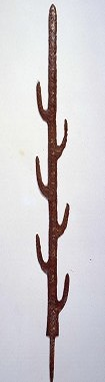


Imageオブジェクトをアスペクト比を維持してリサイズしました。
元のサイズ: 105x382
新しいサイズ: 30x112 (縦方向目標値: 112)



指定された色に変換しました。



指定されたHEXコード #ffffff のピクセルを透明に変換しました。



画像データが配列として生成されました。


In [ ]:
# 画像をロードする
img = load_image("/content/shichishi-to.jpg")

# Uglizerを初期化
ugl = Uglizer(*img, palette=["#7d5b5b","#ffffff"])

# 高さの比率を変更
ugl.resize_height_factor( 1 / scg.gauge_factor)

# サイズを変更
width_pixel, height_pixel= scg.get_pattern_size_of_body()
ugl.resize_pixel((width_pixel,height_pixel))

# パレットの色に変換
ugl.apply_palette()

# 白を透明に変換
ugl.apply_transparent("#ffffff")

# 配列を取得
array = ugl.to_array()

# 配列のカラーコードを変換
conversion_map = {
    '#7D5B5B': '1'
}

pattern = [[conversion_map.get(item, item) for item in row] for row in array]

# patternをNumPy配列に変換
pattern = np.array(pattern)

patterned_chart = scg.get_chart_with_pattern(
    pattern_of_front_body=pattern
)

# チャートをpreadsheetに挿入
exportToSpreadsheet(gc, patterned_chart)